In [26]:
## Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import joblib

# 1. Business Understanding

Credit card fraud can cause financial losses to customers and financial institutions. 
The goal of this project is to develop a machine learning classification model that can 
identify whether a credit card transaction is legitimate or fraudulent.

The model will analyse understandable transaction-related information such as the transaction 
amount, merchant category, customer age, transaction time and location information.

The target variable is `is_fraud`, where:

- `0` represents a legitimate transaction.
- `1` represents a fraudulent transaction.

The project will compare Logistic Regression, Decision Tree and Random Forest models. 
The best model will be selected using precision, recall and F1 score instead of relying only 
on accuracy because the dataset contains significantly fewer fraudulent transactions.

# 2. Data Understanding

## 2.1 Load dataset

In [27]:
# Load the original training and testing datasets
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

# Combine both files into one dataframe for exploration and modelling
df = pd.concat([train_df, test_df], ignore_index=True)

# Display the first five rows
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [28]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display summary statistics for numerical columns
df.describe()

Dataset shape: (1852394, 23)


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,5.371934e+05,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,3.669110e+05,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,2.315490e+05,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,4.630980e+05,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,8.335758e+05,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [29]:
# Display column names, data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

## 2.2 Summary Statistics

In [30]:
# Display all column names
print("Column names:")
print(df.columns.tolist())

# Check for duplicated rows
print("\nNumber of duplicated rows:", df.duplicated().sum())

Column names:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Number of duplicated rows: 0


In [31]:
# Define the target column
target_column = "is_fraud"

# Check for missing values
missing_values = df.isnull().sum()

print("Columns with missing values:")
print(missing_values[missing_values > 0])

# Display the target distribution
print("\nTarget value counts:")
print(df[target_column].value_counts())

print("\nTarget percentages:")
print(df[target_column].value_counts(normalize=True) * 100)

Columns with missing values:
Series([], dtype: int64)

Target value counts:
is_fraud
0    1842743
1       9651
Name: count, dtype: int64

Target percentages:
is_fraud
0    99.478999
1     0.521001
Name: proportion, dtype: float64


In [32]:
# Display statistics for important numerical features
numerical_summary_columns = [
    "amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "is_fraud"
]

df[numerical_summary_columns].describe()

,amt,city_pop,lat,long,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,7.006357e+01,8.864367e+04,3.853931e+01,-9.022783e+01,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.592540e+02,3.014876e+05,5.071470e+00,1.374789e+01,5.105604e+00,1.375969e+01,7.199217e-02
min,1.000000e+00,2.300000e+01,2.002710e+01,-1.656723e+02,1.902742e+01,-1.666716e+02,0.000000e+00
25%,9.640000e+00,7.410000e+02,3.466890e+01,-9.679800e+01,3.474012e+01,-9.689944e+01,0.000000e+00
50%,4.745000e+01,2.443000e+03,3.935430e+01,-8.747690e+01,3.936890e+01,-8.744069e+01,0.000000e+00
75%,8.310000e+01,2.032800e+04,4.194040e+01,-8.015800e+01,4.195626e+01,-8.024511e+01,0.000000e+00
max,2.894890e+04,2.906700e+06,6.669330e+01,-6.795030e+01,6.751027e+01,-6.695090e+01,1.000000e+00


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

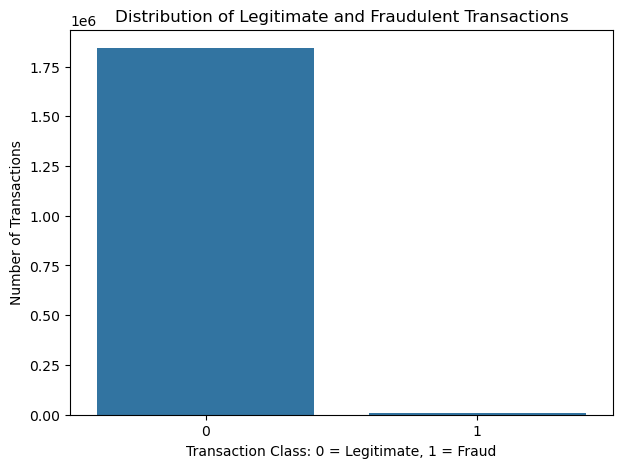

In [33]:
# Plot the number of legitimate and fraudulent transactions
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class: 0 = Legitimate, 1 = Fraud")
plt.ylabel("Number of Transactions")
plt.show()

### Interpretation

The graph shows that legitimate transactions greatly outnumber fraudulent transactions. 
This indicates that the dataset is highly imbalanced.

Because of this imbalance, accuracy alone may provide a misleading evaluation. A model could 
predict most transactions as legitimate and still obtain high accuracy. Therefore, precision, 
recall and F1 score will also be used to evaluate the models.

Recall is especially important because it measures how many actual fraudulent transactions 
are successfully detected.

### 2.3.1.2 Understanding distribution of features

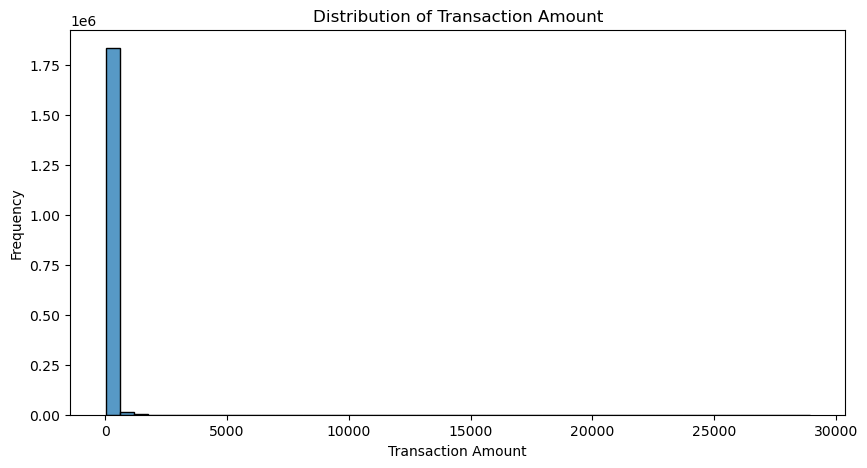

In [34]:
# Plot the distribution of transaction amounts
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amt",
    bins=50
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

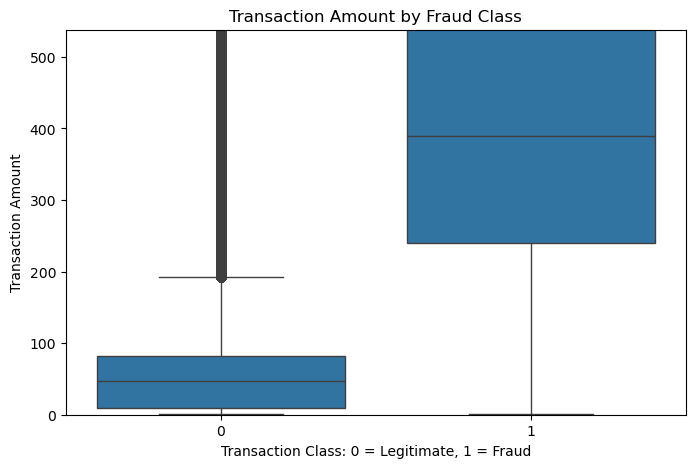

In [35]:
# Compare transaction amounts between legitimate and fraudulent transactions
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amt"
)

plt.title("Transaction Amount by Fraud Class")
plt.xlabel("Transaction Class: 0 = Legitimate, 1 = Fraud")
plt.ylabel("Transaction Amount")
plt.ylim(0, df["amt"].quantile(0.99))
plt.show()


### Interpretation

Most transactions involve relatively small amounts, while a smaller number of transactions 
have very high values. These high-value transactions appear as outliers.

The boxplot compares the amount distribution of legitimate and fraudulent transactions. 
Transaction amount may contribute to fraud detection, but it should be used together with 
other features because both classes can contain low- and high-value transactions.

### 2.3.2 Understanding relationship between variables

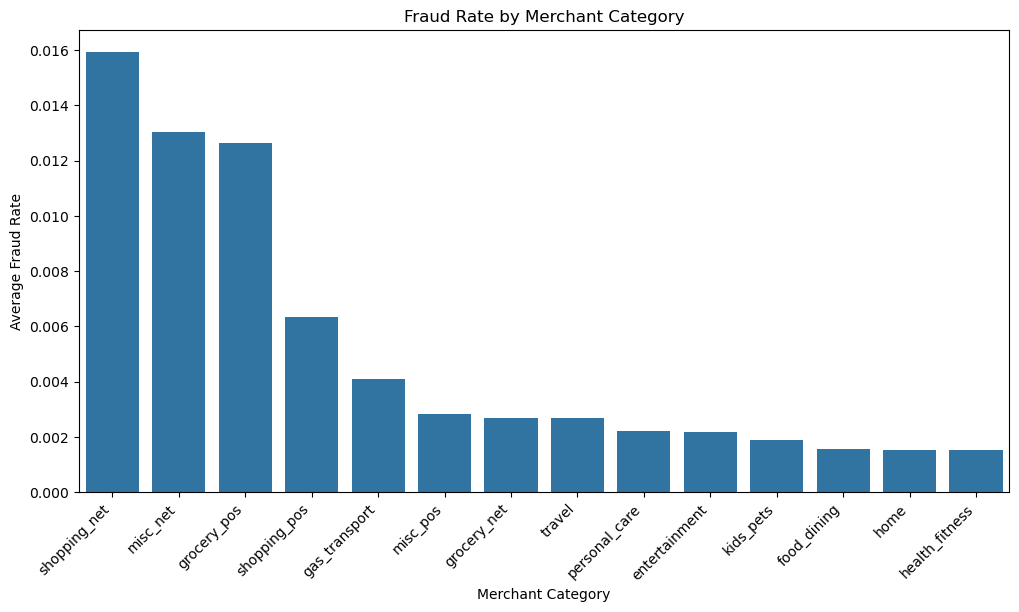

In [36]:
# Calculate the fraud rate for each merchant category
category_fraud_rate = (
    df.groupby("category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_fraud_rate.index,
    y=category_fraud_rate.values
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Average Fraud Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

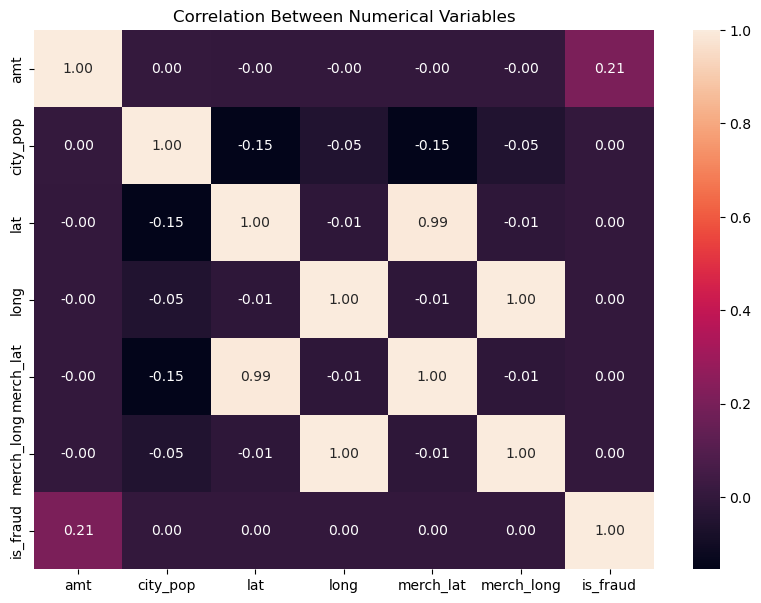

In [37]:
# Select important numerical columns for correlation analysis
correlation_columns = [
    "amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "is_fraud"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

### Interpretation

The merchant category graph shows that fraud rates differ across transaction categories. 
This suggests that merchant category may be useful for predicting fraud.

The correlation heatmap shows the linear relationships between the numerical variables. 
Most correlations with `is_fraud` are relatively weak, suggesting that fraud prediction 
requires a combination of multiple features rather than relying on a single variable.

# 3. Data Preparation

## 3.1 Data Cleaning

In [38]:
# Create a working copy so that the original dataframe remains unchanged
model_df = df.copy()

# Convert date columns into datetime format
model_df["trans_date_trans_time"] = pd.to_datetime(
    model_df["trans_date_trans_time"]
)

model_df["dob"] = pd.to_datetime(
    model_df["dob"]
)

# Create useful features from transaction date and time
model_df["transaction_hour"] = (
    model_df["trans_date_trans_time"].dt.hour
)

model_df["transaction_day"] = (
    model_df["trans_date_trans_time"].dt.dayofweek
)

model_df["transaction_month"] = (
    model_df["trans_date_trans_time"].dt.month
)

# Calculate the customer's age at the time of the transaction
model_df["customer_age"] = (
    model_df["trans_date_trans_time"].dt.year
    - model_df["dob"].dt.year
)

# Remove identifiers, private information and redundant columns
columns_to_drop = [
    "Unnamed: 0",
    "cc_num",
    "trans_num",
    "unix_time",
    "first",
    "last",
    "street",
    "trans_date_trans_time",
    "dob"
]

model_df.drop(
    columns=columns_to_drop,
    inplace=True
)

# Remove duplicated rows
model_df.drop_duplicates(inplace=True)

# Check the cleaned dataframe
print("Cleaned dataset shape:", model_df.shape)
model_df.head()

Cleaned dataset shape: (1852394, 18)


,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,transaction_hour,transaction_day,transaction_month,customer_age
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",36.011293,-82.048315,0,0,1,1,31
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,0,1,1,41
2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0,0,1,1,57
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,47.034331,-112.561071,0,0,1,1,52
4,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,38.674999,-78.632459,0,0,1,1,33


In [39]:
# Select understandable and useful features for modelling
selected_features = [
    "category",
    "amt",
    "gender",
    "state",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "customer_age"
]

X = model_df[selected_features]
y = model_df["is_fraud"]

print("Input features:")
print(X.columns.tolist())

print("\nFeature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Input features:
['category', 'amt', 'gender', 'state', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'transaction_hour', 'transaction_day', 'transaction_month', 'customer_age']

Feature dataset shape: (1852394, 13)
Target dataset shape: (1852394,)


## 3.2 Train-Test Split

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create a copy of the cleaned dataframe
model_df = df.copy()

# Convert date columns
model_df["trans_date_trans_time"] = pd.to_datetime(
    model_df["trans_date_trans_time"]
)

model_df["dob"] = pd.to_datetime(
    model_df["dob"]
)

# Create new features
model_df["transaction_hour"] = (
    model_df["trans_date_trans_time"].dt.hour
)

model_df["transaction_day"] = (
    model_df["trans_date_trans_time"].dt.dayofweek
)

model_df["transaction_month"] = (
    model_df["trans_date_trans_time"].dt.month
)

model_df["customer_age"] = (
    model_df["trans_date_trans_time"].dt.year
    - model_df["dob"].dt.year
)

# Select only the features used for modelling
selected_features = [
    "category",
    "amt",
    "gender",
    "state",
    "city_pop",
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "customer_age"
]

X = model_df[selected_features].copy()
y = model_df["is_fraud"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Encode categorical columns
categorical_columns = [
    "category",
    "gender",
    "state"
]

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    X_train[column] = encoder.fit_transform(
        X_train[column]
    )

    X_test[column] = encoder.transform(
        X_test[column]
    )

    label_encoders[column] = encoder

# Scale numerical columns
numerical_columns = [
    "amt",
    "city_pop",
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "customer_age"
]

scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Columns used:", X_train.columns.tolist())

Training set shape: (1481915, 9)
Testing set shape: (370479, 9)
Columns used: ['category', 'amt', 'gender', 'state', 'city_pop', 'transaction_hour', 'transaction_day', 'transaction_month', 'customer_age']


# 4. Modelling

## 4.1 Train and Compare Models

Three classification algorithms will be tested:

1. Logistic Regression, which provides a simple baseline model.
2. Decision Tree, which can identify non-linear relationships.
3. Random Forest, which combines multiple decision trees and may provide more stable predictions.

The models use `class_weight="balanced"` to give greater importance to the minority fraud class.

In [41]:
# Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [42]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=50,   # Reduce from 100
    max_depth=10,      # Reduce from 15
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


print("Random Forest trained successfully!")

Random Forest trained successfully!


## 4.2 Compare Model Performance

The performance of the three classification models will be compared using:

- Accuracy
- Precision
- Recall
- F1 Score

The model with the highest F1 Score will be selected for further evaluation because the dataset is highly imbalanced.

In [44]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.944437,0.068710,0.769948,0.126162
1,Decision Tree,0.978601,0.192347,0.971503,0.321117
2,Random Forest,0.985656,0.261084,0.958031,0.410342


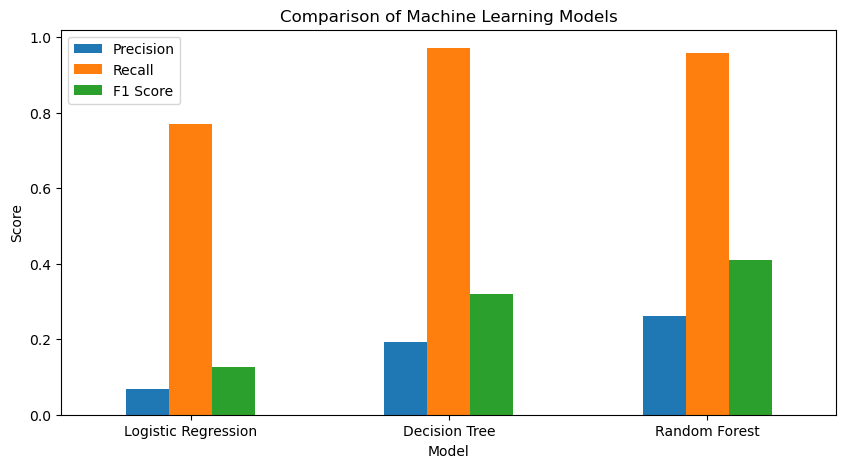

In [45]:
results.set_index("Model")[["Precision","Recall","F1 Score"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# 5. Model Evaluation

In [46]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    368549
           1       0.26      0.96      0.41      1930

    accuracy                           0.99    370479
   macro avg       0.63      0.97      0.70    370479
weighted avg       1.00      0.99      0.99    370479



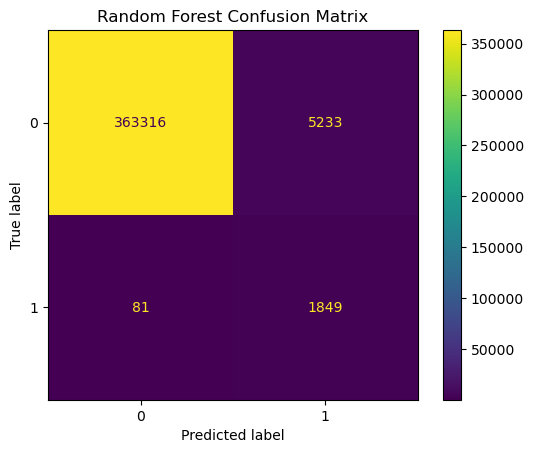

In [47]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

### Interpretation

The confusion matrix shows how many legitimate and fraudulent transactions were classified correctly and incorrectly.

A good fraud detection model should have a high number of true positives while keeping false negatives as low as possible.

# 6. Hyperparameter Tuning

param_dist = {
    "n_estimators":[50,100,150],
    "max_depth":[10,15,20],
    "min_samples_split":[2,5,10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="f1",
    random_state=42
)

random_search.fit(X_train,y_train)

print(random_search.best_params_)

In [48]:
best_model = rf_model

best_pred = rf_model.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    368549
           1       0.26      0.96      0.41      1930

    accuracy                           0.99    370479
   macro avg       0.63      0.97      0.70    370479
weighted avg       1.00      0.99      0.99    370479



In [49]:
joblib.dump(best_model,"fraud_model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(label_encoders,"label_encoders.pkl")
joblib.dump(selected_features,"feature_names.pkl")

print("Model saved successfully!")

Model saved successfully!


In [50]:
import pandas as pd

sample = X_test.iloc[[0]].copy()

print("Original prediction:", rf_model.predict(sample)[0])

sample["amt"] = 500000

print("Prediction after changing amount:", rf_model.predict(sample)[0])

if hasattr(rf_model, "predict_proba"):
    print("Probability:", rf_model.predict_proba(sample))

Original prediction: 0
Prediction after changing amount: 0
Probability: [[0.66142782 0.33857218]]
